<a href="https://colab.research.google.com/github/w1t1ta/Project_01/blob/main/test_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


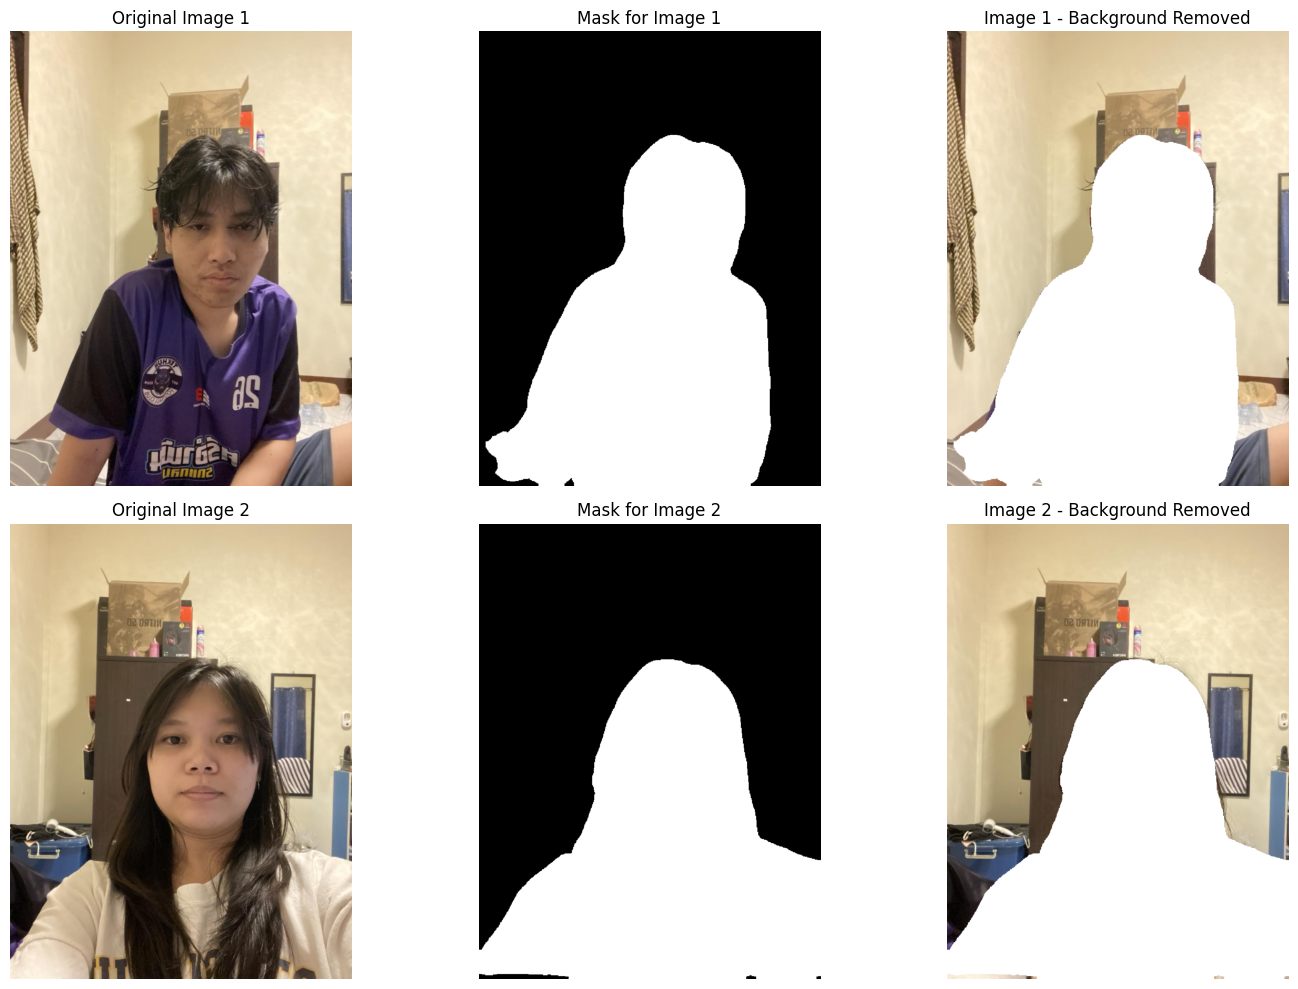

บันทึกไฟล์เสร็จสมบูรณ์!


In [11]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# โหลดโมเดล DeepLabV3+
deeplab_model = deeplabv3_resnet101(pretrained=True).eval()
transform = T.Compose([T.Resize(520), T.ToTensor()])

# โหลดภาพจาก path
def load_image_from_path(path):
    image = Image.open(path).convert("RGB")
    return image

# ใช้ DeepLabV3+ แยกตัวบุคคลออกจากภาพ และเก็บเฉพาะพื้นหลัง
def remove_person_from_background(image):
    input_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = deeplab_model(input_tensor)["out"][0]

    mask = output.argmax(0).byte().cpu().numpy()
    mask_resized = cv2.resize(mask, (image.width, image.height), interpolation=cv2.INTER_NEAREST)

    # สร้าง mask ที่ลบตัวบุคคล (ค่า 15 คือ class ของบุคคลใน DeepLabV3+)
    person_mask = mask_resized != 15  # ค่า 15 คือ class ของบุคคล

    # สร้างภาพที่มี alpha channel เพื่อแสดงพื้นหลัง
    img_array = np.array(image)
    img_array_with_alpha = np.dstack([img_array, np.uint8(person_mask) * 255])  # พื้นหลังที่ไม่รวมตัวบุคคล

    return Image.fromarray(img_array_with_alpha, "RGBA"), mask_resized

# **กำหนดเส้นทางของไฟล์ภาพที่บันทึก**
path1 = "/content/484306100_1607547476614172_7718928177540118125_n.jpg"
path2 = "/content/484780875_954835580188785_170552539904722165_n.jpg"

# โหลดและแยกพื้นหลัง (ลบตัวบุคคล)
image1 = load_image_from_path(path1)
image2 = load_image_from_path(path2)

# ลบตัวบุคคลออกจากภาพ
background1, mask1 = remove_person_from_background(image1)
background2, mask2 = remove_person_from_background(image2)

# แสดงผลลัพธ์ในรูปแบบ 3 คอลัมน์ 2 แถว
plt.figure(figsize=(15,10))

plt.subplot(2, 3, 1)
plt.imshow(image1)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask1, cmap='gray')
plt.title("Mask for Image 1")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(background1)
plt.title("Image 1 - Background Removed")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(image2)
plt.title("Original Image 2")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask2, cmap='gray')
plt.title("Mask for Image 2")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(background2)
plt.title("Image 2 - Background Removed")
plt.axis("off")

plt.tight_layout()
plt.show()

import os

# สร้างโฟลเดอร์ output ถ้ายังไม่มี
output_folder = "/content/output"
os.makedirs(output_folder, exist_ok=True)

# **บันทึกภาพที่ได้**
def save_image(image, path):
    # Convert the image to RGB mode before saving if it has an alpha channel
    if image.mode == 'RGBA':
        image = image.convert('RGB')
    image.save(path)

# กำหนดเส้นทางการบันทึก
path1_original = os.path.join(output_folder, "484306100_1607547476614172_7718928177540118125_n_original.jpg")
path1_mask = os.path.join(output_folder, "484306100_1607547476614172_7718928177540118125_n_mask.jpg")
path1_background = os.path.join(output_folder, "484306100_1607547476614172_7718928177540118125_n_no_bg.jpg")

path2_original = os.path.join(output_folder, "484780875_954835580188785_170552539904722165_n_original.jpg")
path2_mask = os.path.join(output_folder, "484780875_954835580188785_170552539904722165_n_mask.jpg")
path2_background = os.path.join(output_folder, "484780875_954835580188785_170552539904722165_n_no_bg.jpg")

# บันทึกภาพต้นฉบับ
image1.save(path1_original)
image2.save(path2_original)

# บันทึกมาสก์
mask1_image = Image.fromarray(mask1)
mask2_image = Image.fromarray(mask2)
mask1_image.save(path1_mask)
mask2_image.save(path2_mask)

# บันทึกภาพที่ลบพื้นหลัง
save_image(background1, path1_background)
save_image(background2, path2_background)

print("บันทึกไฟล์เสร็จสมบูรณ์!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Original Image Size: (828, 1104)
Original Image Size: (828, 1104)


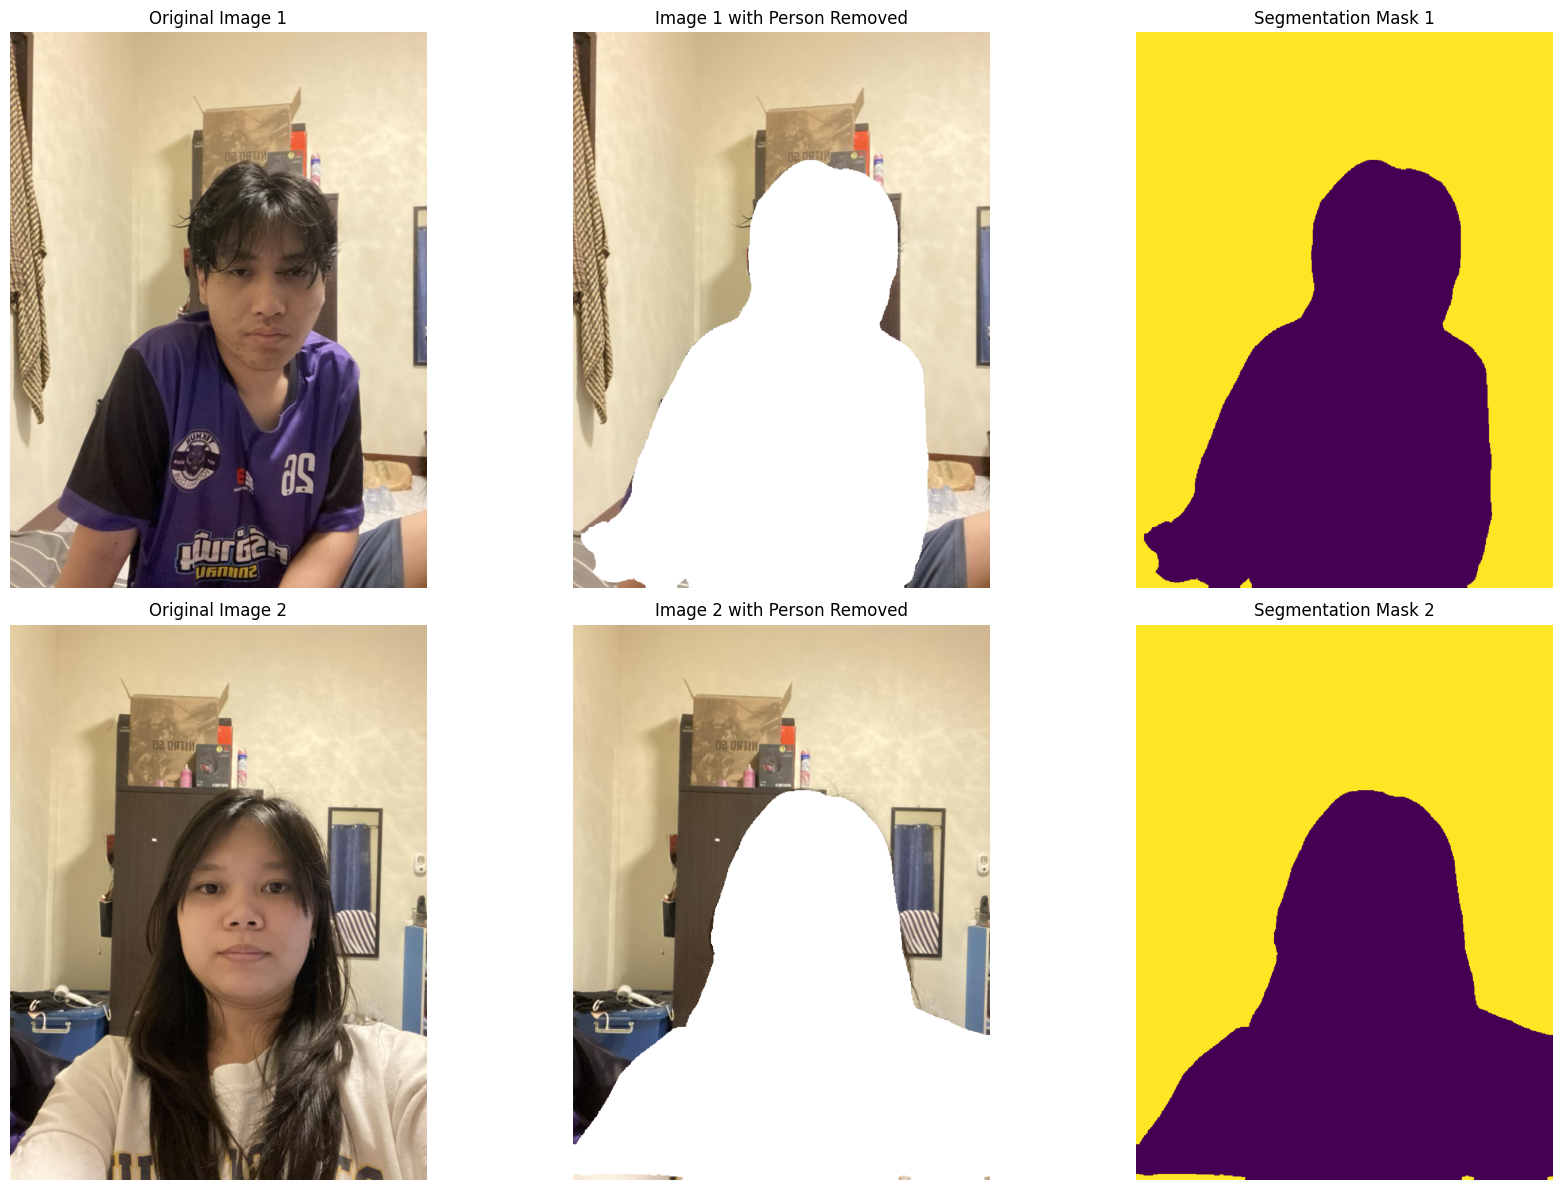

Images have been saved to the 'output' folder.


In [6]:
!pip install opencv-python
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from torchvision import models
import cv2

# โหลดโมเดล DeepLabV3+ ที่พรีเทรนแล้ว
model = models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # ตั้งโมเดลเป็นโหมดทำนาย

# โหลดภาพที่ต้องการทดสอบ
image_path1 = '/content/484306100_1607547476614172_7718928177540118125_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 1
image_path2 = '/content/484780875_954835580188785_170552539904722165_n.jpg'  # กำหนดเส้นทางภาพที่ต้องการทดสอบ 2

# ฟังก์ชันในการประมวลผลภาพ
def process_image(image_path):
    image = Image.open(image_path)

    # ตรวจสอบขนาดของภาพก่อนทำการแปลง
    print(f"Original Image Size: {image.size}")

    # แปลงภาพจาก PIL เป็น Tensor สำหรับโมเดล
    transform = T.Compose([T.Resize(520), T.ToTensor()])
    input_image = transform(image).unsqueeze(0)  # แปลงเป็น tensor และเพิ่ม batch dimension

    # ทำนายผลลัพธ์
    with torch.no_grad():
        output = model(input_image)['out'][0]  # นำผลลัพธ์จากโมเดล
    output_predictions = output.argmax(0)  # ใช้ argmax เพื่อหา class ที่สูงที่สุด

    # สร้าง mask เพื่อหาพื้นหลัง
    person_mask = output_predictions != 15  # 15 คือตัวเลขของบุคคลใน DeepLabV3+

    # แปลง person_mask เป็น NumPy array
    person_mask_np = person_mask.cpu().numpy()

    # Resize the mask to the original image size
    person_mask_np = cv2.resize(person_mask_np.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)

    # แปลงภาพเป็น numpy array
    image_array = np.array(image)

    # สร้างภาพใหม่ที่ลบบุคคลออกจากภาพ (โดยการใช้ mask)
    image_with_no_person = np.dstack([image_array, person_mask_np * 255])

    # แปลงกลับเป็นภาพ PIL
    result_image = Image.fromarray(image_with_no_person)

    return image, result_image, person_mask_np

# ประมวลผลภาพทั้งสอง
image1, result_image1, mask1 = process_image(image_path1)
image2, result_image2, mask2 = process_image(image_path2)

# แสดงภาพทั้งสอง
fig, axarr = plt.subplots(2, 3, figsize=(18, 12))

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพแรก
axarr[0, 0].imshow(image1)
axarr[0, 0].set_title('Original Image 1')
axarr[0, 0].axis('off')

axarr[0, 1].imshow(result_image1)
axarr[0, 1].set_title('Image 1 with Person Removed')
axarr[0, 1].axis('off')

axarr[0, 2].imshow(Image.fromarray(mask1.astype(np.uint8) * 255))
axarr[0, 2].set_title('Segmentation Mask 1')
axarr[0, 2].axis('off')

# แสดงภาพต้นฉบับและผลลัพธ์สำหรับภาพที่สอง
axarr[1, 0].imshow(image2)
axarr[1, 0].set_title('Original Image 2')
axarr[1, 0].axis('off')

axarr[1, 1].imshow(result_image2)
axarr[1, 1].set_title('Image 2 with Person Removed')
axarr[1, 1].axis('off')

axarr[1, 2].imshow(Image.fromarray(mask2.astype(np.uint8) * 255))
axarr[1, 2].set_title('Segmentation Mask 2')
axarr[1, 2].axis('off')

plt.tight_layout()
plt.show()

# บันทึกผลลัพธ์ลงในโฟลเดอร์ 'output'
output_folder = 'output'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# บันทึกภาพต้นฉบับ
image1.save(os.path.join(output_folder, 'original_image1.jpg'))
image2.save(os.path.join(output_folder, 'original_image2.jpg'))

# บันทึกภาพผลลัพธ์
result_image1.save(os.path.join(output_folder, 'image1_with_person_removed.png'))
result_image2.save(os.path.join(output_folder, 'image2_with_person_removed.png'))

# บันทึก segmentation mask
Image.fromarray(mask1.astype(np.uint8) * 255).save(os.path.join(output_folder, 'segmentation_mask1.png'))
Image.fromarray(mask2.astype(np.uint8) * 255).save(os.path.join(output_folder, 'segmentation_mask2.png'))

print("Images have been saved to the 'output' folder.")


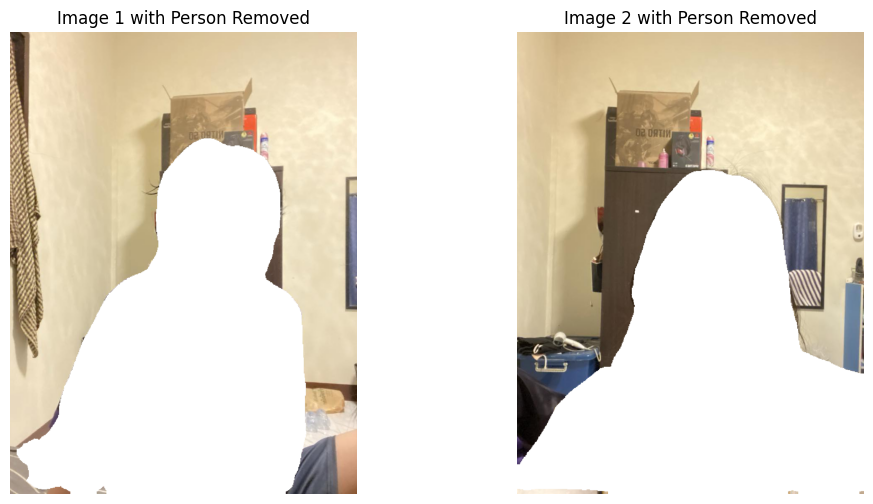

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

# โหลดภาพจาก path ที่บันทึกไว้
image_path1 = "/content/output/image1_with_person_removed.png"
image_path2 = "/content/output/image2_with_person_removed.png"

image1 = Image.open(image_path1)
image2 = Image.open(image_path2)

# แสดงภาพ
fig, axarr = plt.subplots(1, 2, figsize=(12, 6))

# แสดงภาพแรก
axarr[0].imshow(image1)
axarr[0].set_title("Image 1 with Person Removed")
axarr[0].axis("off")

# แสดงภาพที่สอง
axarr[1].imshow(image2)
axarr[1].set_title("Image 2 with Person Removed")
axarr[1].axis("off")

plt.show()

In [1]:

!pip install torch torchvision torchaudio --quiet

!pip install git+https://github.com/openai/CLIP.git --quiet
!pip install timm --quiet
!pip install git+https://github.com/facebookresearch/dinov2.git --quiet
!pip install git+https://github.com/facebookresearch/ImageBind.git --quiet
!pip install huggingface_hub transformers --quiet

#กำหนด path ของภาพที่ต้องการเปรียบเทียบ
img_path1 = "/content/output/image1_with_person_removed.png"  # ระบุ path ของภาพแรก
img_path2 = "/content/output/image2_with_person_removed.png"  # ระบุ path ของภาพที่สอง

#โหลดโมเดลและฟังก์ชัน
import torch
import clip
from PIL import Image
from torchvision import transforms
import timm
from dinov2.models.vision_transformer import vit_base
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType
from imagebind.data import load_and_transform_vision_data
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"

# === 1. CLIP ===
def get_clip_similarity(img1_path, img2_path):
    model, preprocess = clip.load("ViT-B/32", device=device)
    img1 = preprocess(Image.open(img1_path)).unsqueeze(0).to(device)
    img2 = preprocess(Image.open(img2_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        f1 = model.encode_image(img1)
        f2 = model.encode_image(img2)
    return torch.cosine_similarity(f1, f2).item()

# === 2. DINOv2 ===
def get_dinov2_similarity(img1_path, img2_path):
    model = vit_base(pretrained=True).to(device).eval()
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=0.5),
    ])
    img1 = transform(Image.open(img1_path)).unsqueeze(0).to(device)
    img2 = transform(Image.open(img2_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        f1 = model(img1)
        f2 = model(img2)
    return torch.cosine_similarity(f1, f2).item()

# === 3. ImageBind ===
def get_imagebind_similarity(img1_path, img2_path):
    model = imagebind_model.imagebind_huge(pretrained=True)
    model.eval().to(device)
    vision_embeds = {}
    for i, path in enumerate([img1_path, img2_path]):
        inputs = {
            ModalityType.VISION: load_and_transform_vision_data([path], device)
        }
        with torch.no_grad():
            embed = model(inputs)[ModalityType.VISION]
        vision_embeds[i] = embed
    return torch.cosine_similarity(vision_embeds[0], vision_embeds[1]).item()

# === 4. ReVA ===
def get_reva_similarity(img1_path, img2_path):
    from transformers import AutoProcessor, AutoModel
    processor = AutoProcessor.from_pretrained("NAVER/reva-clip-vit-base-patch32")
    model = AutoModel.from_pretrained("NAVER/reva-clip-vit-base-patch32").to(device)
    images = [Image.open(img1_path).convert("RGB"), Image.open(img2_path).convert("RGB")]
    inputs = processor(images=images, return_tensors="pt").to(device)
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    return torch.cosine_similarity(image_features[0].unsqueeze(0), image_features[1].unsqueeze(0)).item()

#เปรียบเทียบและแสดงผลลัพธ์

print("CLIP similarity:", get_clip_similarity(img_path1, img_path2))
print("DINOv2 similarity:", get_dinov2_similarity(img_path1, img_path2))
print("ImageBind similarity:", get_imagebind_similarity(img_path1, img_path2))
print("ReVA similarity:", get_reva_similarity(img_path1, img_path2))

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement xformers==0.0.18 (from dinov2) (from versions: 0.0.1, 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.0.8, 0.0.9, 0.0.10, 0.0.11, 0.0.12, 0.0.13, 0.0.16rc424, 0.0.16rc425, 0.0.16, 0.0.20, 0.0.21, 0.0.22, 0.0.22.post7, 0.0.23, 0.0.23.post1, 0.0.24, 0.0.25, 0.0.25.post1, 0.0.26.post1, 0.0.27, 0.0.27.post1, 0.0.27.post2, 0.0.28, 0.0.28.post1, 0.0.28.post2, 0.0.28.post3, 0.0.29, 0.0.29.post1, 0.0.29.post2, 0.0.29.post3, 0.0.30.dev1004, 0.0.30.dev1005)
ERROR: No matching distribution found for xformers==0.0.18
  Preparing 

ModuleNotFoundError: No module named 'dinov2'